In [1]:
# importing various libraries
import numpy as np
import pandas as pd
# importing the dataset
# Load the feature datasets
X_train_scaled_df = pd.read_csv('../../data/processed/X_train_scaled.csv')
X_val_scaled_df = pd.read_csv('../../data/processed/X_val_scaled.csv')
X_unseen_scaled_df = pd.read_csv('../../data/processed/X_unseen_scaled.csv')

# Load the label datasets as 1D arrays
y_train = pd.read_csv('../../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../../data/processed/y_val.csv').values.ravel()
y_unseen = pd.read_csv('../../data/processed/y_unseen.csv').values.ravel()

# Check the shapes to ensure they are correct
print(X_train_scaled_df.shape, y_train.shape)
print(X_val_scaled_df.shape, y_val.shape)
print(X_unseen_scaled_df.shape, y_unseen.shape)


(907672, 12) (907672,)
(389003, 12) (389003,)
(555719, 12) (555719,)


In [2]:
X_train_scaled_df.head()

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,0.345657,0.047743,0.391304,0.454545,0.335400,0.147239,0.450749,0.134523,0.265507,0.471296,1.000000,1.0
1,0.055513,1.000000,0.565217,0.000000,0.572920,0.417178,0.268176,0.145714,0.304951,0.169627,0.529474,0.0
2,0.026249,0.012681,0.608696,0.090909,0.255791,0.478528,0.324890,0.145714,0.312038,0.019611,0.529474,1.0
3,0.182132,0.003241,0.608696,0.454545,0.632953,0.736196,0.274984,0.145714,0.178402,0.000000,0.529474,0.0
4,0.023130,0.383052,0.913043,1.000000,0.095269,0.368098,0.212649,0.155150,0.310707,0.250640,1.000000,1.0


In [3]:
X_val_scaled_df.head()

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,0.058892,0.000282,0.869565,0.181818,0.326917,0.588957,0.374344,0.122630,0.274701,0.022581,0.702629,0.0
1,0.032850,0.057344,0.913043,0.636364,0.075693,0.220859,0.717075,0.081477,0.246744,0.022581,0.815279,0.0
2,0.002131,0.047361,0.913043,0.454545,0.050897,0.417178,0.182525,0.000000,0.099430,0.169627,0.702629,0.0
3,0.238113,0.031158,0.652174,0.454545,1.078630,0.294479,0.528490,0.134523,0.246744,0.126064,1.000000,1.0
4,0.546293,0.033432,0.521739,0.909091,0.105057,0.147239,0.262418,0.165364,0.246042,0.000000,0.815279,0.0


In [4]:
y_train

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [5]:
y_val

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [6]:
y_unseen

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [7]:
X_unseen_scaled_df.head()

,amt,city_pop,trans_hour,trans_month,timedelta_last_trans,cust_age,distance_from_prev_merch,state_WOE,job_WOE,category_WOE,trans_dayofweek_WOE,gender_M
0,0.642765,0.032647,0.565217,0.454545,0.831321,0.257669,0.841275,0.148779,0.347469,0.022581,0.028068,0.0
1,0.402937,0.032647,0.695652,0.454545,0.129853,0.257669,0.817953,0.148779,0.347469,0.270028,0.028068,0.0
2,0.333961,0.032647,0.304348,0.454545,0.608157,0.257669,0.861393,0.148779,0.347469,0.471296,0.000000,0.0
3,0.450861,0.032647,0.652174,0.454545,0.295595,0.257669,0.847543,0.148779,0.347469,0.126064,0.000000,0.0
4,0.764187,0.032647,0.521739,0.454545,0.819576,0.257669,0.843158,0.148779,0.347469,0.169627,0.529474,0.0


## validating the model

Estimate for scale_pos_weight: 171.758
Validation Accuracy: 0.9945398878671887
Validation Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.52      0.95      0.67      2252

    accuracy                           0.99    389003
   macro avg       0.76      0.97      0.83    389003
weighted avg       1.00      0.99      1.00    389003

Validation Confusion Matrix:
 [[384749   2002]
 [   122   2130]]
Validation ROC AUC Score: 0.9978818543770203
Validation PR AUC Score: 0.9206999835120637


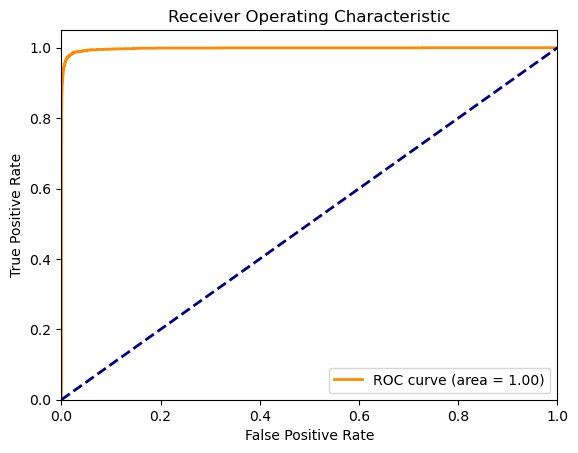

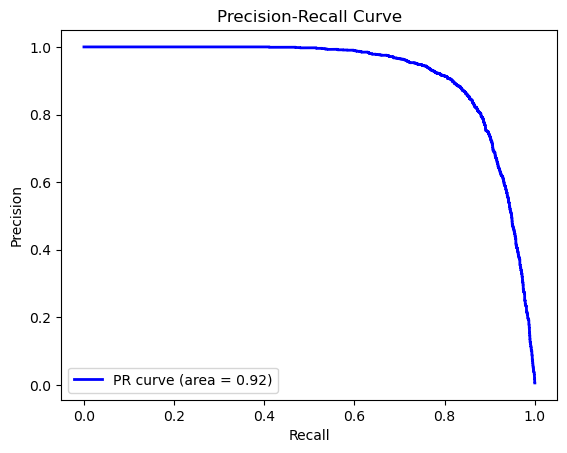

CPU times: total: 20.3 s
Wall time: 2.8 s


In [8]:
%%time
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from collections import Counter

# Calculate scale_pos_weight
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print('Estimate for scale_pos_weight: %.3f' % scale_pos_weight)

# Define the initial XGBoost model
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Train the model on the training data
xgb_model.fit(X_train_scaled_df, y_train)

# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_scaled_df)
y_val_pred_proba = xgb_model.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

## testing the model without tunning

Unseen Data Accuracy: 0.9929514736764444
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.29      0.59      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.79      0.70    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix:
 [[550529   3045]
 [   872   1273]]
Unseen Data ROC AUC Score: 0.9558754258395138
Unseen Data PR AUC Score: 0.530886665056799


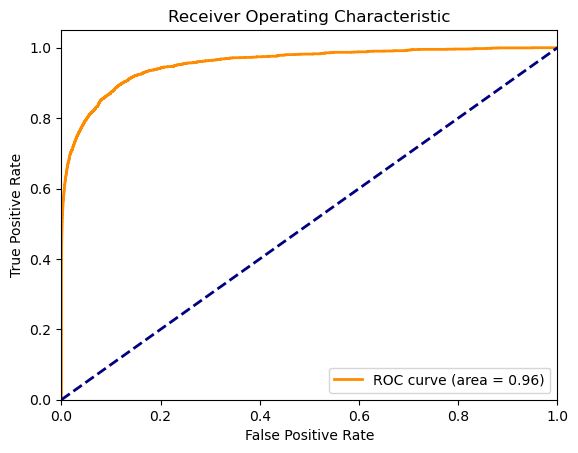

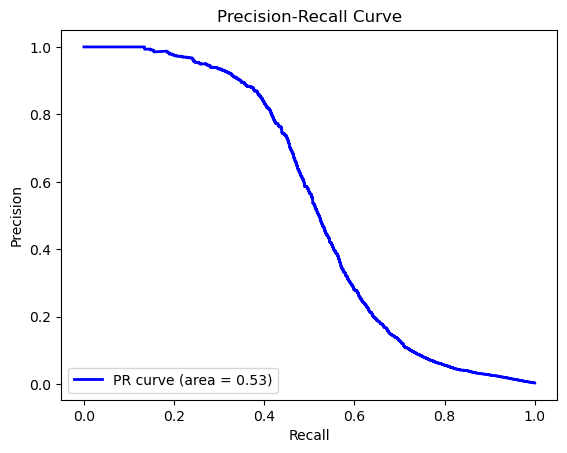

In [9]:
# Make predictions on the unseen data
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Use a default threshold of 0.5 to convert probabilities to binary predictions
y_unseen_pred = (y_unseen_pred_proba >= 0.5).astype(int)

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


## tunning the model

In [10]:
import pandas as pd

# Verify class distribution
print("y_train distribution:\n", pd.Series(y_train).value_counts())
print("y_val distribution:\n", pd.Series(y_val).value_counts())
print("y_unseen distribution:\n", pd.Series(y_unseen).value_counts())


y_train distribution:
 0    902418
1      5254
Name: count, dtype: int64
y_val distribution:
 0    386751
1      2252
Name: count, dtype: int64
y_unseen distribution:
 0    553574
1      2145
Name: count, dtype: int64


In [11]:
from sklearn.metrics import make_scorer, f1_score

f1_scorer = make_scorer(f1_score, pos_label=1)

In [16]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9994 ± 0.0000, Test: 0.9986 ± 0.0001
Precision - Train: 0.9909 ± 0.0010, Test: 0.9473 ± 0.0037
Recall - Train: 0.9122 ± 0.0034, Test: 0.8034 ± 0.0128
F1 - Train: 0.9499 ± 0.0022, Test: 0.8694 ± 0.0077
Roc_auc - Train: 0.9999 ± 0.0000, Test: 0.9985 ± 0.0003
CPU times: total: 1min 54s
Wall time: 11 s


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution
param_dist = {
    'scale_pos_weight': randint(1, 1000),
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'learning_rate': uniform(0.01, 0.19)
}

# Initialize the RandomizedSearchCV
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=strat_k_fold,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    refit=True
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    random_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", random_search.best_score_)


Best Parameters: {'learning_rate': 0.11548815420389784, 'max_depth': 30, 'n_estimators': 162, 'scale_pos_weight': 2}
Best Cross-Validation ROC AUC Score: 0.9982740670916979


Unseen Data Accuracy: 0.9975257279308427
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.80      0.48      0.60      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.74      0.80    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[553310    264]
 [  1111   1034]]
Unseen Data ROC AUC Score: 0.9818898672961545
Unseen Data PR AUC Score: 0.6115650072336366


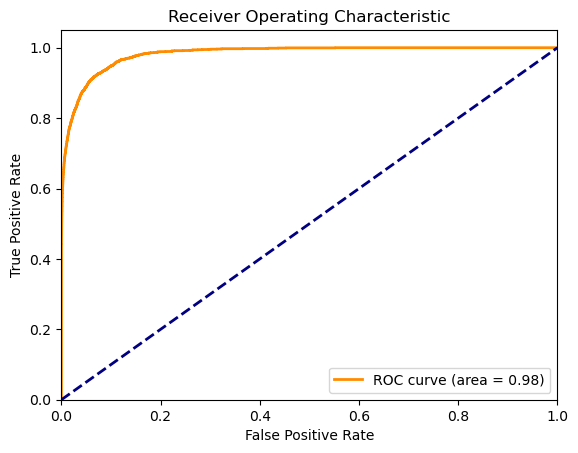

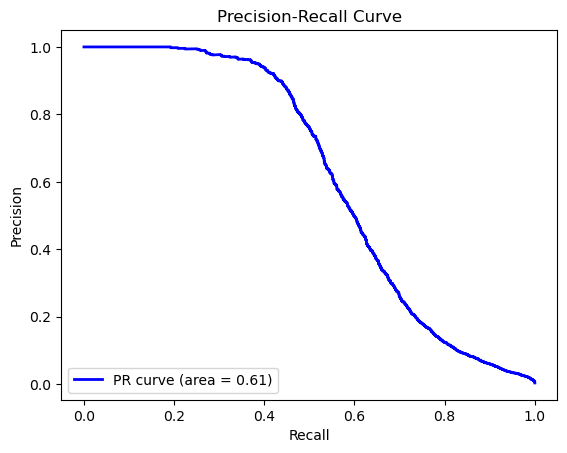

In [18]:
# Make predictions on the unseen data
y_unseen_pred = random_search.best_estimator_.predict(X_unseen_scaled_df)
y_unseen_pred_proba = random_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]


# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()


Best Threshold: 0.3064783
Unseen Data Accuracy (Tuned Threshold): 0.997408762342119
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.73      0.51      0.61      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.76      0.80    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553176    398]
 [  1042   1103]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9818898672961545
Unseen Data PR AUC Score (Tuned Threshold): 0.6115650072336366


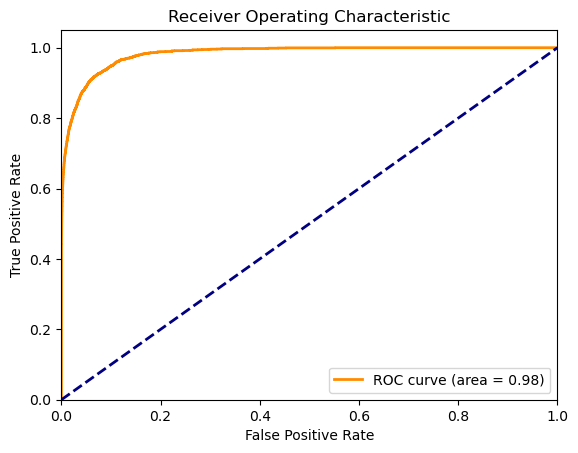

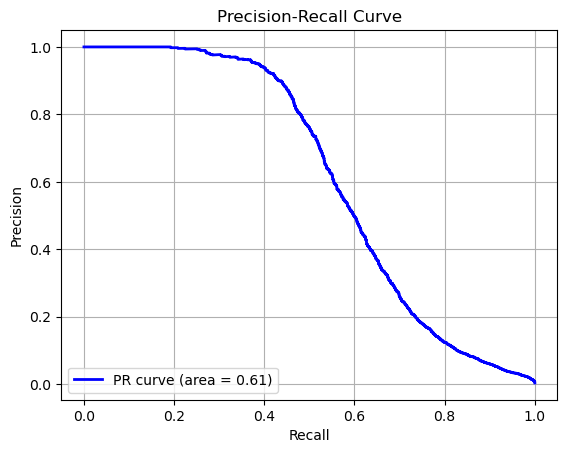

In [20]:
# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % auc(recall, precision))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()


Best Threshold for target precision: 0.020973295
Unseen Data Accuracy (Tuned Threshold): 0.9956128906875598
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.45      0.62      0.52      2145

    accuracy                           1.00    555719
   macro avg       0.72      0.81      0.76    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[551959   1615]
 [   823   1322]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9818898672961545
Unseen Data PR AUC Score (Tuned Threshold): 0.6115650072336366


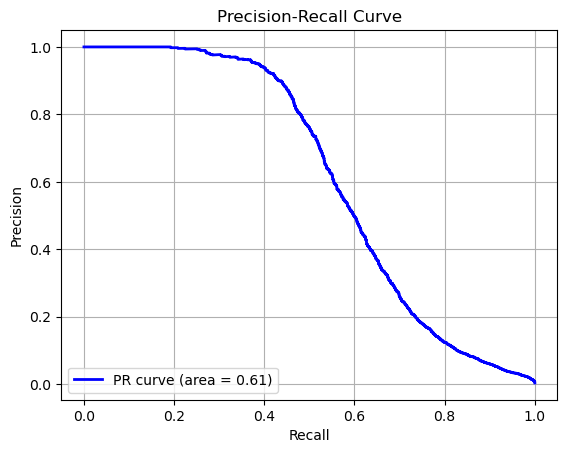

In [21]:
# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Find the threshold where precision is around 0.45
target_precision = 0.45
index = np.where(precision >= target_precision)[0][0]  # Find the first index where precision is at least 0.45

best_threshold = thresholds[index]
print("Best Threshold for target precision:", best_threshold)

# Apply the new threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % auc(recall, precision))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()


******************************************************************************************************************

In [33]:
from xgboost import XGBClassifier

# Define the XGBoost model with the best parameters
xgb_model = XGBClassifier(
    scale_pos_weight=25,
    n_estimators=200,
    max_depth=None,
    learning_rate=0.1,
    random_state=42
)

# Train the model on the combined dataset
xgb_model.fit(X_train_scaled_df, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [34]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_scaled_df, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9975 ± 0.0001, Test: 0.9967 ± 0.0002
Precision - Train: 0.6991 ± 0.0104, Test: 0.6549 ± 0.0112
Recall - Train: 0.9896 ± 0.0022, Test: 0.9242 ± 0.0069
F1 - Train: 0.8193 ± 0.0078, Test: 0.7666 ± 0.0097
Roc_auc - Train: 0.9998 ± 0.0000, Test: 0.9983 ± 0.0003
CPU times: total: 3min 11s
Wall time: 20.8 s


In [35]:
%%time
from sklearn.model_selection import cross_validate, StratifiedKFold
X_combined = pd.concat([X_train_scaled_df, X_val_scaled_df])
y_combined = np.concatenate([y_train, y_val])
# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_combined, y_combined, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9972 ± 0.0001, Test: 0.9966 ± 0.0001
Precision - Train: 0.6748 ± 0.0078, Test: 0.6452 ± 0.0042
Recall - Train: 0.9832 ± 0.0014, Test: 0.9337 ± 0.0035
F1 - Train: 0.8003 ± 0.0059, Test: 0.7631 ± 0.0029
Roc_auc - Train: 0.9998 ± 0.0000, Test: 0.9986 ± 0.0003
CPU times: total: 4min 34s
Wall time: 30.9 s


Unseen Data Accuracy: 0.9951882156269626
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.41      0.58      0.48      2145

    accuracy                           1.00    555719
   macro avg       0.71      0.79      0.74    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix:
 [[551802   1772]
 [   902   1243]]
Unseen Data ROC AUC Score: 0.9629393675206882
Unseen Data PR AUC Score: 0.5536225721375164


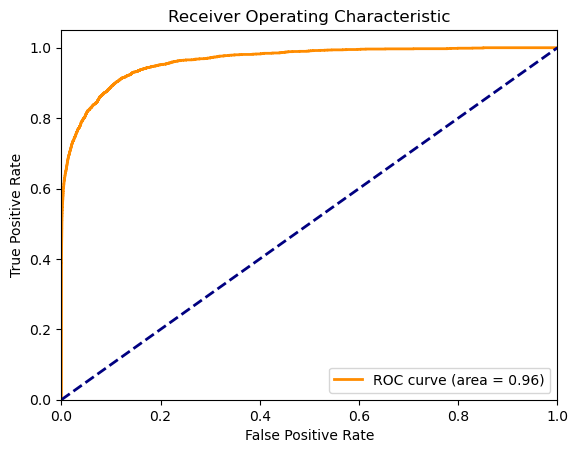

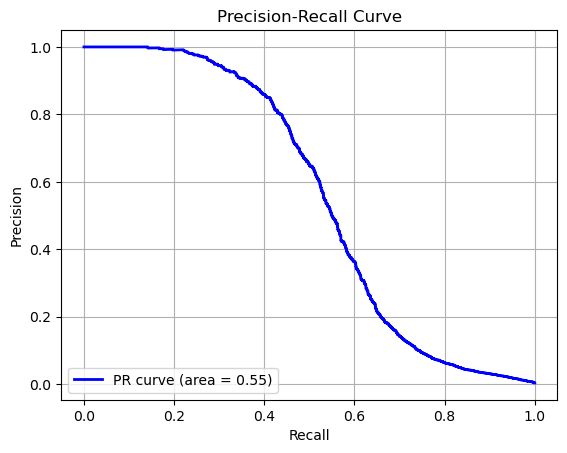

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Make predictions on the unseen data
y_unseen_pred = xgb_model.predict(X_unseen_scaled_df)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

***************************

In [38]:
%%time
from sklearn.model_selection import RandomizedSearchCV
import joblib
from scipy.stats import randint, uniform

# Define the parameter grid
param_grid = {
    'scale_pos_weight': randint(1, 1000),
    'n_estimators': randint(50, 200),
    'max_depth': [None] + list(range(1, 31)),
    'learning_rate': uniform(0.01, 0.2)
}

# Initialize the RandomizedSearchCV
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=100,
    cv=strat_k_fold,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    refit='roc_auc'
)

# Perform the search with threading backend
with joblib.parallel_backend('threading'):
    random_search.fit(X_train_scaled_df, y_train)

# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", random_search.best_score_)


Best Parameters: {'learning_rate': 0.1821461166512687, 'max_depth': 6, 'n_estimators': 186, 'scale_pos_weight': 318}
Best Cross-Validation ROC AUC Score: 0.998239697016639
CPU times: total: 6h 48min 40s
Wall time: 16min 43s


Validation Data Accuracy: 0.993683853337892
Validation Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    386751
           1       0.48      0.95      0.64      2252

    accuracy                           0.99    389003
   macro avg       0.74      0.97      0.82    389003
weighted avg       1.00      0.99      0.99    389003

Validation Data Confusion Matrix:
 [[384405   2346]
 [   111   2141]]
Validation Data ROC AUC Score: 0.9981229213790067
Validation Data PR AUC Score: 0.9238325844386425


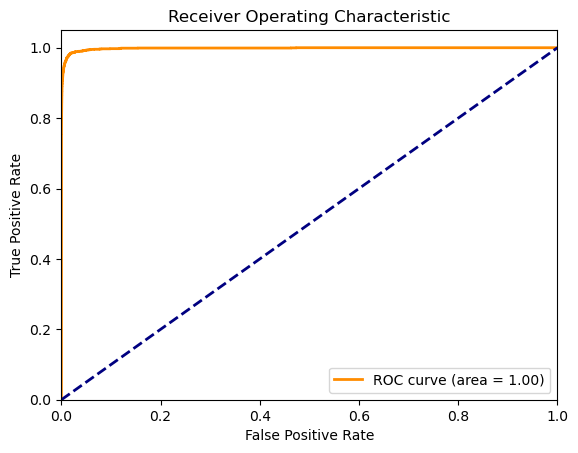

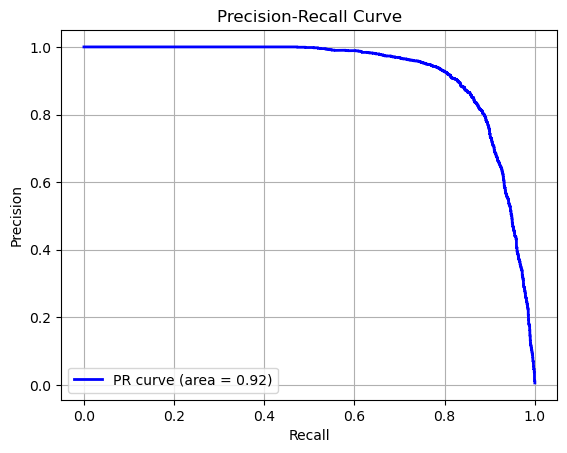

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Make predictions on the validation data
y_val_pred = random_search.best_estimator_.predict(X_val_scaled_df)
y_val_pred_proba = random_search.best_estimator_.predict_proba(X_val_scaled_df)[:, 1]

# Evaluate the model on the validation data
print("Validation Data Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Data Classification Report:\n", classification_report(y_val, y_val_pred))
print("Validation Data Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Validation Data ROC AUC Score:", roc_auc_score(y_val, y_val_pred_proba))
print("Validation Data PR AUC Score:", average_precision_score(y_val, y_val_pred_proba))

# Plot ROC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()


Unseen Data Accuracy: 0.9922100917909951
Unseen Data Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.27      0.60      0.37      2145

    accuracy                           0.99    555719
   macro avg       0.63      0.79      0.68    555719
weighted avg       1.00      0.99      0.99    555719

Unseen Data Confusion Matrix:
 [[550113   3461]
 [   868   1277]]
Unseen Data ROC AUC Score: 0.9502469660533441
Unseen Data PR AUC Score: 0.5213672156064719


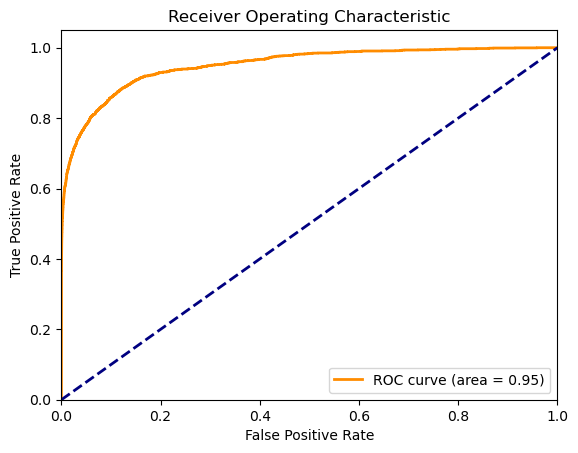

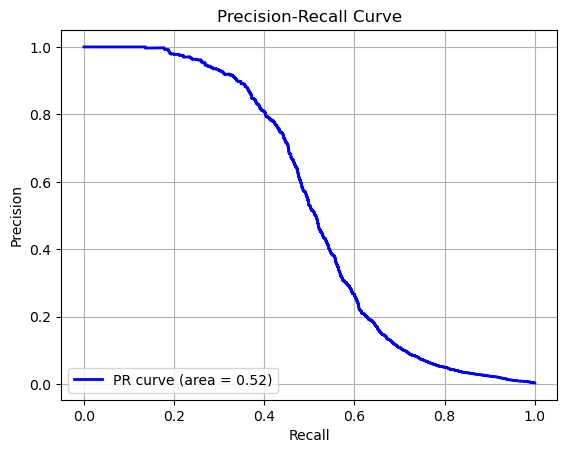

In [41]:
# Make predictions on the unseen data
y_unseen_pred = random_search.best_estimator_.predict(X_unseen_scaled_df)
y_unseen_pred_proba = random_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Evaluate the model on the unseen data
print("Unseen Data Accuracy:", accuracy_score(y_unseen, y_unseen_pred))
print("Unseen Data Classification Report:\n", classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:\n", confusion_matrix(y_unseen, y_unseen_pred))
print("Unseen Data ROC AUC Score:", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score:", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()


Best Threshold: 0.9685015
Unseen Data Accuracy (Tuned Threshold): 0.9972504089296929
Unseen Data Classification Report (Tuned Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.74      0.44      0.55      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.72      0.78    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Tuned Threshold):
 [[553244    330]
 [  1198    947]]
Unseen Data ROC AUC Score (Tuned Threshold): 0.9502469660533441
Unseen Data PR AUC Score (Tuned Threshold): 0.5213672156064719


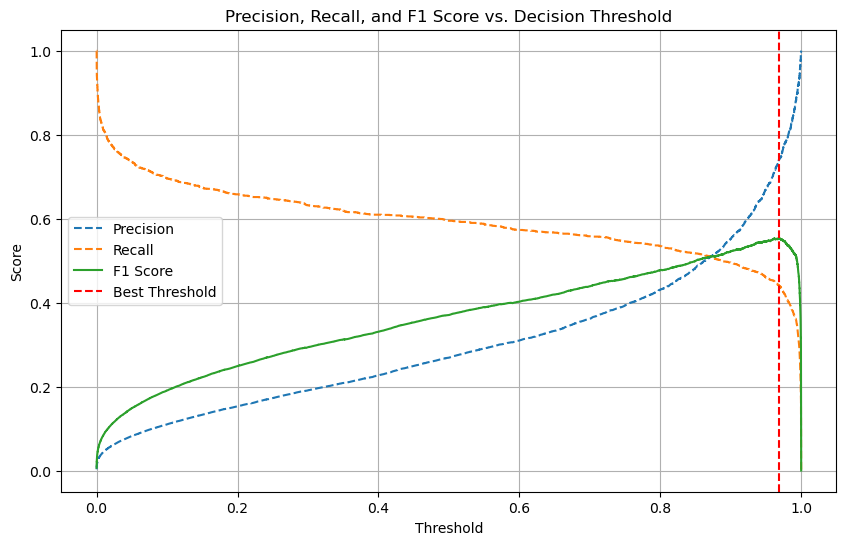

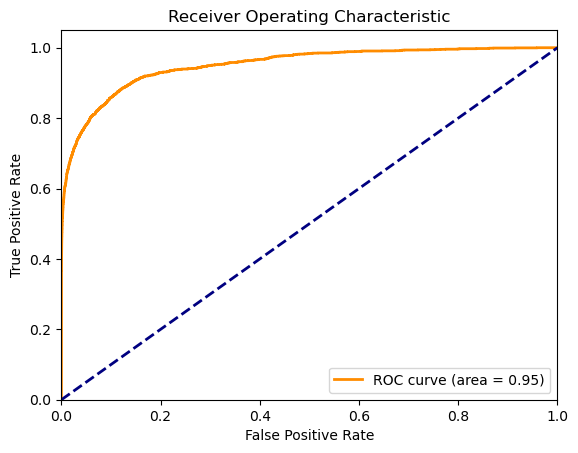

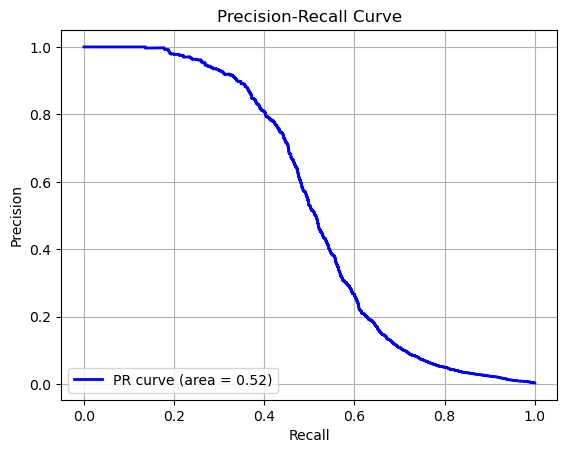

In [42]:
# Make predictions on the unseen data
y_unseen_pred_proba = random_search.best_estimator_.predict_proba(X_unseen_scaled_df)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_unseen, y_unseen_pred_proba)

# Calculate F1 scores for all thresholds
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the threshold that maximizes the F1-score
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)

# Apply the best threshold to the predictions
y_unseen_pred_tuned = (y_unseen_pred_proba >= best_threshold).astype(int)

# Evaluate the tuned threshold predictions
print("Unseen Data Accuracy (Tuned Threshold):", accuracy_score(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Classification Report (Tuned Threshold):\n", classification_report(y_unseen, y_unseen_pred_tuned))
print("Unseen Data Confusion Matrix (Tuned Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_tuned))
print("Unseen Data ROC AUC Score (Tuned Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Tuned Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=best_threshold, color='r', linestyle='--', label="Best Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()


Unseen Data Accuracy (Fixed Threshold): 0.9960015763362419
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.48      0.52      0.50      2145

    accuracy                           1.00    555719
   macro avg       0.74      0.76      0.75    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[552387   1187]
 [  1035   1110]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9502469660533441
Unseen Data PR AUC Score (Fixed Threshold): 0.5213672156064719


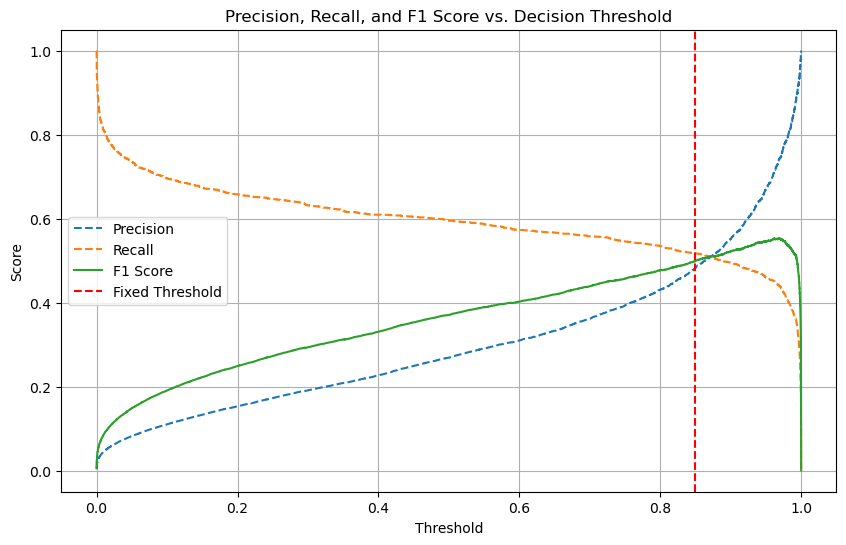

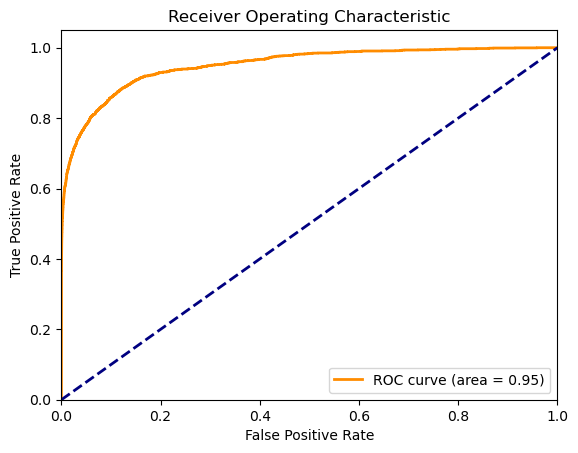

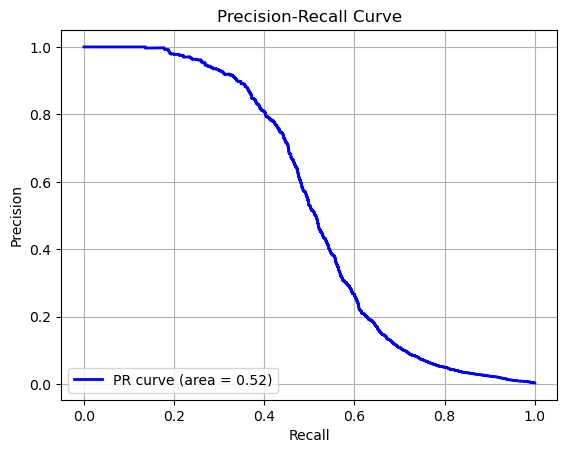

In [43]:
# Define the fixed threshold
fixed_threshold = 0.

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot Precision-Recall curve and F1 score
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precision", linestyle='--')
plt.plot(thresholds, recall[:-1], label="Recall", linestyle='--')
plt.plot(thresholds, f1_scores[:-1], label="F1 Score")
plt.axvline(x=fixed_threshold, color='r', linestyle='--', label="Fixed Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score vs. Decision Threshold")
plt.legend(loc="best")
plt.grid()
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()


***************************